# 딥러닝심화 과제 5 - CycleGAN 실습 및 개선
#### 컴퓨터공학부 인공지능공학과 20231049 정우제
<hr>

## 목차
<hr>

0. [필요한 라이브러리 불러오기](#0-필요한-라이브러리-불러오기)
1. [실험 1: Transform 기법 비교 (torchvision)](#1-실험-1-transform-기법-비교-torchvision)
2. [실험 2: 하이퍼파라미터 최적화](#2-실험-2-하이퍼파라미터-최적화)
3. [실험 3: 생성기 및 판별기 구조 개선](#3-실험-3-생성기-및-판별기-구조-개선)
4. [실험 4: Generator-Discriminator Normalization 조합](#4-실험-4-generator-discriminator-normalization-조합)
5. [실험 5: 고급 Transform 기법 (Albumentations)](#5-실험-5-고급-transform-기법-albumentations)
6. [실험 6: 논문 기반 개선](#6-실험-6-논문-기반-개선)
7. [결론 및 분석](#7-결론-및-분석)
8. [결과 이미지](#8-결과-이미지)

## 0. 필요한 라이브러리 불러오기
<hr>

In [48]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import itertools
import cv2
import random
import gc
import subprocess

In [2]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, mode='train', transforms=None):
        self.transform = transforms
        self.dir_A = os.path.join(data_dir, f'{mode}A')
        self.dir_B = os.path.join(data_dir, f'{mode}B')
        self.files_A = sorted([os.path.join(self.dir_A, f) for f in os.listdir(self.dir_A) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.files_B = sorted([os.path.join(self.dir_B, f) for f in os.listdir(self.dir_B) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.length = min(len(self.files_A), len(self.files_B))
        
    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        img_A = Image.open(self.files_A[index % len(self.files_A)]).convert('RGB')
        img_B = Image.open(self.files_B[index % len(self.files_B)]).convert('RGB')
        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)
        
        return img_A, img_B

## 1. 실험 1: Transform 기법 비교 (torchvision)
<hr>

In [3]:
def get_transform_configs():    
    transform_configs = {
        # 1. 기본 설정
        'baseline': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 2. 강한 Augmentation
        'strong_aug': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 3. 약한 Augmentation
        'light_aug': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 4. Resize 방식 변경 (LANCZOS)
        'lanczos_resize': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.LANCZOS),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 5. 더 큰 초기 Resize
        'large_resize': transforms.Compose([
            transforms.Resize(int(256*1.3), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 6. Center Crop (
        'center_crop': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.CenterCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 7. Augmentation 없음 
        'minimal': transforms.Compose([
            transforms.Resize(256, Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 8. Vertical Flip 추가
        'vertical_flip': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 9. Gaussian Blur 추가
        'with_blur': transforms.Compose([
            transforms.Resize(int(256*1.12), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]),
        
        # 10. 다양한 Augmentation 조합
        'combined_aug': transforms.Compose([
            transforms.Resize(int(256*1.15), Image.BICUBIC),
            transforms.RandomCrop(256),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
            transforms.RandomRotation(5),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    }
    
    return transform_configs

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels)
        )
    
    def forward(self, x):
        return x + self.block(x)

In [5]:
class GeneratorResNet(nn.Module):
    def __init__(self, in_channels, num_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        
        out_channels=64
        self.conv = nn.Sequential(
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(in_channels, out_channels, 2*in_channels+1),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        
        channels = out_channels
        
        self.down = []
        for _ in range(2):
            out_channels = channels * 2
            self.down += [
                nn.Conv2d(channels, out_channels, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ]
            channels = out_channels
        self.down = nn.Sequential(*self.down)
        
        self.trans = [ResidualBlock(channels) for _ in range(num_residual_blocks)]
        self.trans = nn.Sequential(*self.trans)
        
        self.up = []
        for _ in range(2):
            out_channels = channels // 2
            self.up += [
                nn.Upsample(scale_factor=2),
                nn.Conv2d(channels, out_channels, 3, stride=1, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ]
            channels = out_channels
        self.up = nn.Sequential(*self.up)
        
        self.out = nn.Sequential(
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(channels, in_channels, 2*in_channels+1),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.down(x)
        x = self.trans(x)
        x = self.up(x)
        x = self.out(x)
        return x


In [6]:
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            *self.block(in_channels, 64, normalize=False),
            *self.block(64, 128),
            *self.block(128, 256),
            *self.block(256, 512),
            
            nn.ZeroPad2d((1,0,1,0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )
        
        self.scale_factor = 16
    
    @staticmethod
    def block(in_channels, out_channels, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        return layers
        
    def forward(self, x):
        return self.model(x)

In [16]:
def train_cyclegan(transform_name, data_dir, batch_size=5, n_epoches=100, decay_epoch=20, 
                   lr=0.0002, device='cuda'):    
    print(f"\n{'='*60}")
    print(f"Training with transform: {transform_name}")
    print(f"{'='*60}")
    
    # DataLoader 생성
    transform_configs = get_transform_configs()
    transforms_ = transform_configs[transform_name]
    
    trainloader = DataLoader(
        ImageDataset(data_dir, mode='train', transforms=transforms_),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    testloader = DataLoader(
        ImageDataset(data_dir, mode='test', transforms=transforms_),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    
    # 모델 초기화
    G_XY = GeneratorResNet(3, num_residual_blocks=9).to(device)
    D_Y = Discriminator(3).to(device)
    G_YX = GeneratorResNet(3, num_residual_blocks=9).to(device)
    D_X = Discriminator(3).to(device)
    
    # Loss functions
    criterion_GAN = nn.MSELoss().to(device)
    criterion_cycle = nn.L1Loss().to(device)
    criterion_identity = nn.L1Loss().to(device)
    
    # Optimizers
    b1, b2 = 0.5, 0.999
    optimizer_G = torch.optim.Adam(
        itertools.chain(G_XY.parameters(), G_YX.parameters()), 
        lr=lr, betas=(b1, b2)
    )
    optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    # Learning rate schedulers
    lambda_func = lambda epoch: 1 - max(0, epoch-decay_epoch)/(n_epoches-decay_epoch)
    lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_func)
    lr_scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_func)
    lr_scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_func)
    
    # Training loop
    for epoch in range(n_epoches):
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            # Ground truth
            out_shape = [real_X.size(0), 1, real_X.size(2)//D_X.scale_factor, real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)
            
            # Train Generators
            G_XY.train()
            G_YX.train()
            
            optimizer_G.zero_grad()
            
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            
            fake_YY = G_XY(real_Y)
            fake_XX = G_YX(real_X)        
            
            # Identity loss
            loss_id_X = criterion_identity(fake_XX, real_X)
            loss_id_Y = criterion_identity(fake_YY, real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            # GAN loss
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid) 
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            # Cycle loss
            recov_X = G_YX(fake_Y)
            recov_Y = G_XY(fake_X)
            loss_cycle_X = criterion_cycle(recov_X, real_X)
            loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            # Total G loss
            loss_G = 5.0*loss_identity + loss_GAN + 10.0*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            # Train Discriminator X
            optimizer_D_X.zero_grad()
            
            loss_real = criterion_GAN(D_X(real_X), valid)
            loss_fake = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real + loss_fake) / 2
            
            loss_D_X.backward()
            optimizer_D_X.step()
            
            # Train Discriminator Y
            optimizer_D_Y.zero_grad()
            
            loss_real = criterion_GAN(D_Y(real_Y), valid)
            loss_fake = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real + loss_fake) / 2
            
            loss_D_Y.backward()
            optimizer_D_Y.step()
        
        lr_scheduler_G.step()
        lr_scheduler_D_X.step()
        lr_scheduler_D_Y.step()
        
        # Print progress
        if (epoch+1) % 10 == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'[Epoch {epoch+1}/{n_epoches}]')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
    
    return G_XY, G_YX, D_X, D_Y

In [17]:
def generate_images(G_YX, data_dir, save_dir, batch_size=5, device='cuda'):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # testB 폴더에서 이미지 로드
    photo_dir = os.path.join(data_dir, 'testB')
    files = sorted([os.path.join(photo_dir, name) for name in os.listdir(photo_dir) 
                    if name.endswith(('jpg', 'png', 'jpeg'))])
    
    print(f"Generating {len(files)} images to {save_dir}")
    
    # Transform 정의
    generate_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    to_image = transforms.ToPILImage()
    
    G_YX.eval()
    with torch.no_grad():
        for i in range(0, len(files), batch_size):
            # Read images
            imgs = []
            for j in range(i, min(len(files), i+batch_size)):
                img = Image.open(files[j])
                img = generate_transforms(img)
                imgs.append(img)
            imgs = torch.stack(imgs, 0).to(device)
            
            # Generate
            fake_imgs = G_YX(imgs).detach().cpu()
            
            # Save
            for j in range(fake_imgs.size(0)):
                img = fake_imgs[j].squeeze().permute(1, 2, 0)
                img_arr = img.numpy()
                img_arr = (img_arr - np.min(img_arr)) * 255 / (np.max(img_arr) - np.min(img_arr))
                img_arr = img_arr.astype(np.uint8)
                
                img = to_image(img_arr)
                _, name = os.path.split(files[i+j])
                img.save(os.path.join(save_dir, name))
    
    print(f"Saved {len(files)} images to {save_dir}")

In [18]:
def train_all_transforms(data_dir='./data/ukiyoe2photo/', 
                         base_save_dir='cyclegan_results',
                         batch_size=5, 
                         n_epoches=100,
                         decay_epoch=20,
                         device=None):
    
    # Device 설정
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    
    print(f"Using device: {device}")
    
    # 모든 transform 설정 가져오기
    transform_configs = get_transform_configs()
    
    results = {}
    
    for transform_name in transform_configs.keys():
        # 학습
        G_XY, G_YX, D_X, D_Y = train_cyclegan(
            transform_name=transform_name,
            data_dir=data_dir,
            batch_size=batch_size,
            n_epoches=n_epoches,
            decay_epoch=decay_epoch,
            device=device
        )
        
        # 이미지 생성 및 저장
        save_dir = os.path.join(base_save_dir, f'photo2ukiyoe_{transform_name}')
        generate_images(G_YX, data_dir, save_dir, batch_size=batch_size, device=device)
        
        results[transform_name] = {
            'save_dir': save_dir,
            'G_XY': G_XY,
            'G_YX': G_YX,
            'D_X': D_X,
            'D_Y': D_Y
        }
        
        print(f"\nCompleted: {transform_name}")
        print(f"Images saved to: {save_dir}\n")
    
    return results

In [20]:
results = train_all_transforms(
        data_dir='./data/ukiyoe2photo/',
        base_save_dir='cyclegan_results',
        batch_size=5,
        n_epoches=50,  
        decay_epoch=20
    )

Using device: cuda

Training with transform: baseline
[Epoch 10/50]
[G loss: 4.1568 | identity: 0.2172 GAN: 0.4828 cycle: 0.2588]
[D loss: 0.1881 | D_X: 0.2286 D_Y: 0.1475]
[Epoch 20/50]
[G loss: 4.2137 | identity: 0.2202 GAN: 0.7159 cycle: 0.2397]
[D loss: 0.0671 | D_X: 0.0652 D_Y: 0.0691]
[Epoch 30/50]
[G loss: 2.9800 | identity: 0.1515 GAN: 0.6049 cycle: 0.1618]
[D loss: 0.1491 | D_X: 0.1607 D_Y: 0.1375]
[Epoch 40/50]
[G loss: 2.5750 | identity: 0.1431 GAN: 0.3649 cycle: 0.1494]
[D loss: 0.2100 | D_X: 0.1646 D_Y: 0.2554]
[Epoch 50/50]
[G loss: 2.1501 | identity: 0.1081 GAN: 0.4687 cycle: 0.1141]
[D loss: 0.1640 | D_X: 0.1728 D_Y: 0.1552]
Generating 751 images to cyclegan_results/photo2ukiyoe_baseline
Saved 751 images to cyclegan_results/photo2ukiyoe_baseline

Completed: baseline
Images saved to: cyclegan_results/photo2ukiyoe_baseline


Training with transform: strong_aug
[Epoch 10/50]
[G loss: 3.8758 | identity: 0.1946 GAN: 0.4183 cycle: 0.2484]
[D loss: 0.2097 | D_X: 0.2867 D_Y: 0.

[Epoch 40/50]
[G loss: 2.5895 | identity: 0.1363 GAN: 0.5254 cycle: 0.1383]
[D loss: 0.1160 | D_X: 0.1409 D_Y: 0.0911]
[Epoch 50/50]
[G loss: 2.0926 | identity: 0.1020 GAN: 0.6020 cycle: 0.0981]
[D loss: 0.1330 | D_X: 0.1190 D_Y: 0.1470]
Generating 751 images to cyclegan_results/photo2ukiyoe_with_blur
Saved 751 images to cyclegan_results/photo2ukiyoe_with_blur

Completed: with_blur
Images saved to: cyclegan_results/photo2ukiyoe_with_blur


Training with transform: combined_aug
[Epoch 10/50]
[G loss: 4.2621 | identity: 0.2220 GAN: 0.5365 cycle: 0.2616]
[D loss: 0.0897 | D_X: 0.0780 D_Y: 0.1015]
[Epoch 20/50]
[G loss: 3.6508 | identity: 0.1936 GAN: 0.5291 cycle: 0.2153]
[D loss: 0.1099 | D_X: 0.1052 D_Y: 0.1146]
[Epoch 30/50]
[G loss: 2.9551 | identity: 0.1312 GAN: 0.6040 cycle: 0.1695]
[D loss: 0.2156 | D_X: 0.2298 D_Y: 0.2014]
[Epoch 40/50]
[G loss: 3.0813 | identity: 0.1437 GAN: 0.4080 cycle: 0.1955]
[D loss: 0.1176 | D_X: 0.1253 D_Y: 0.1099]
[Epoch 50/50]
[G loss: 2.4782 | identity: 

In [40]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_results'
device = 'cuda:0'

transform_names = [
    'baseline', 'strong_aug', 'light_aug', 'lanczos_resize', 'large_resize',
    'center_crop', 'minimal', 'vertical_flip', 'with_blur', 'combined_aug'
]

fid_results = {}

for name in transform_names:
    folder_path = os.path.join(base_dir, f'photo2ukiyoe_{name}')
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testB_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results[name] = fid_value

In [41]:
fid_results

{'baseline': 223.1158604942621,
 'strong_aug': 232.49472651707296,
 'light_aug': 222.58247548928975,
 'lanczos_resize': 223.1437120813489,
 'large_resize': 230.0861439893506,
 'center_crop': 225.82031450316825,
 'minimal': 211.3426471145444,
 'vertical_flip': 222.31790551911314,
 'with_blur': 220.98803899986757,
 'combined_aug': 229.51429396664824}

## 2. 실험 2: 하이퍼파라미터 최적화
<hr>

In [47]:
def train_cyclegan2(transform_name, 
                   data_dir, 
                   batch_size=5, 
                   n_epoches=100, 
                   decay_epoch=20, 
                   lr=0.0002,
                   lambda_identity=5.0,
                   lambda_cycle=10.0,
                   lambda_gan=1.0,
                   optimizer_type='Adam',
                   gan_loss_type='MSE',
                   device='cuda'):

    # DataLoader 생성
    transform_configs = get_transform_configs()
    transforms_ = transform_configs[transform_name]
    
    trainloader = DataLoader(
        ImageDataset(data_dir, mode='train', transforms=transforms_),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    testloader = DataLoader(
        ImageDataset(data_dir, mode='test', transforms=transforms_),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )
    
    # 모델 초기화
    G_XY = GeneratorResNet(3, num_residual_blocks=9).to(device)
    D_Y = Discriminator(3).to(device)
    G_YX = GeneratorResNet(3, num_residual_blocks=9).to(device)
    D_X = Discriminator(3).to(device)
    
    # Loss functions
    if gan_loss_type == 'MSE':
        criterion_GAN = nn.MSELoss().to(device)
    elif gan_loss_type == 'BCE':
        criterion_GAN = nn.BCEWithLogitsLoss().to(device)
    else:
        criterion_GAN = nn.MSELoss().to(device)
    
    criterion_cycle = nn.L1Loss().to(device)
    criterion_identity = nn.L1Loss().to(device)
    
    # Optimizers
    b1, b2 = 0.5, 0.999
    
    if optimizer_type == 'Adam':
        optimizer_G = torch.optim.Adam(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, betas=(b1, b2)
        )
        optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
        optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    elif optimizer_type == 'AdamW':
        optimizer_G = torch.optim.AdamW(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, betas=(b1, b2)
        )
        optimizer_D_X = torch.optim.AdamW(D_X.parameters(), lr=lr, betas=(b1, b2))
        optimizer_D_Y = torch.optim.AdamW(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    elif optimizer_type == 'RMSprop':
        optimizer_G = torch.optim.RMSprop(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr
        )
        optimizer_D_X = torch.optim.RMSprop(D_X.parameters(), lr=lr)
        optimizer_D_Y = torch.optim.RMSprop(D_Y.parameters(), lr=lr)
    
    elif optimizer_type == 'SGD':
        optimizer_G = torch.optim.SGD(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, momentum=0.9
        )
        optimizer_D_X = torch.optim.SGD(D_X.parameters(), lr=lr, momentum=0.9)
        optimizer_D_Y = torch.optim.SGD(D_Y.parameters(), lr=lr, momentum=0.9)
    
    else:
        optimizer_G = torch.optim.Adam(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, betas=(b1, b2)
        )
        optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
        optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    # Learning rate schedulers
    lambda_func = lambda epoch: 1 - max(0, epoch-decay_epoch)/(n_epoches-decay_epoch)
    lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_func)
    lr_scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_func)
    lr_scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_func)
    
    # Training loop
    for epoch in range(n_epoches):
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            # Ground truth
            out_shape = [real_X.size(0), 1, real_X.size(2)//D_X.scale_factor, real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)
            
            # Train Generators
            G_XY.train()
            G_YX.train()
            
            optimizer_G.zero_grad()
            
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            
            fake_YY = G_XY(real_Y)
            fake_XX = G_YX(real_X)        
            
            # Identity loss
            loss_id_X = criterion_identity(fake_XX, real_X)
            loss_id_Y = criterion_identity(fake_YY, real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            # GAN loss
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid) 
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            # Cycle loss
            recov_X = G_YX(fake_Y)
            recov_Y = G_XY(fake_X)
            loss_cycle_X = criterion_cycle(recov_X, real_X)
            loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            # Total G loss 
            loss_G = lambda_identity*loss_identity + lambda_gan*loss_GAN + lambda_cycle*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            # Train Discriminator X
            optimizer_D_X.zero_grad()
            
            loss_real = criterion_GAN(D_X(real_X), valid)
            loss_fake = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real + loss_fake) / 2
            
            loss_D_X.backward()
            optimizer_D_X.step()
            
            # Train Discriminator Y
            optimizer_D_Y.zero_grad()
            
            loss_real = criterion_GAN(D_Y(real_Y), valid)
            loss_fake = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real + loss_fake) / 2
            
            loss_D_Y.backward()
            optimizer_D_Y.step()
        
        lr_scheduler_G.step()
        lr_scheduler_D_X.step()
        lr_scheduler_D_Y.step()

        if (epoch+1) % 10 == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'[Epoch {epoch+1}/{n_epoches}]')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
    
    return G_XY, G_YX, D_X, D_Y

In [61]:
def train_all_experiments(data_dir='./data/ukiyoe2photo/', 
                         base_save_dir='cyclegan_experiments',
                         transform_name='minimal',  
                         n_epoches=100,
                         decay_epoch=20,
                         device=None):
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    
    print(f"Using device: {device}")
    
    # 실험 설정들
    experiments = {
        # Lambda 값 실험
        'lambda_3_15': {'lambda_identity': 3.0, 'lambda_cycle': 15.0},
        'lambda_10_10': {'lambda_identity': 10.0, 'lambda_cycle': 10.0},
        'lambda_1_10': {'lambda_identity': 1.0, 'lambda_cycle': 10.0},
        'lambda_5_20': {'lambda_identity': 5.0, 'lambda_cycle': 20.0},
        
        # 학습률 실험
        'lr_0.0001': {'lr': 0.0001},
        'lr_0.0003': {'lr': 0.0003},
        'lr_0.0005': {'lr': 0.0005},
        
        # Optimizer 실험
        'opt_AdamW': {'optimizer_type': 'AdamW'},
        'opt_RMSprop': {'optimizer_type': 'RMSprop'},
        
        # 배치 크기 실험
        'batch_2': {'batch_size': 2},
        'batch_6': {'batch_size': 6},
        'batch_8': {'batch_size': 8},
        
        # Loss 함수 실험
        'loss_BCE': {'gan_loss_type': 'BCE'},
    }
    
    # 기본 설정
    default_config = {
        'batch_size': 5,
        'lr': 0.0002,
        'lambda_identity': 5.0,
        'lambda_cycle': 10.0,
        'lambda_gan': 1.0,
        'optimizer_type': 'Adam',
        'gan_loss_type': 'MSE'
    }
    
    results = {}
    
    for exp_name, exp_params in experiments.items():
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_name}")
        print(f"{'='*60}")
        
        # 현재 실험의 전체 설정 (기본값 + 변경값)
        current_config = default_config.copy()
        current_config.update(exp_params)
        

        folder_name = (f"{transform_name}_bs{current_config['batch_size']}_"
                      f"lr{current_config['lr']}_"
                      f"lambda{current_config['lambda_identity']}-{current_config['lambda_cycle']}_"
                      f"{current_config['optimizer_type']}_"
                      f"{current_config['gan_loss_type']}")
        
        save_dir = os.path.join(base_save_dir, folder_name)

        if os.path.exists(save_dir):
            existing_files = [f for f in os.listdir(save_dir) if f.endswith(('jpg', 'png', 'jpeg'))]
            if len(existing_files) >= 750:
                print(f"already completed: {folder_name}")
                results[exp_name] = {
                    'save_dir': save_dir,
                    'config': current_config,
                    'status': 'skipped'
                }
                continue
        
        
        # 학습
        G_XY, G_YX, D_X, D_Y = train_cyclegan2(
            transform_name=transform_name,
            data_dir=data_dir,
            n_epoches=n_epoches,
            decay_epoch=decay_epoch,
            device=device,
            **current_config
        )
        
        # 이미지 생성
        batch_size = current_config['batch_size']
        generate_images(G_YX, data_dir, save_dir, batch_size=batch_size, device=device)
        

        results[exp_name] = {
            'save_dir': save_dir,
            'config': current_config,
            'status': 'completed'
        }
        
        print(f"   Completed: {exp_name}")
        print(f"   Images saved to: {save_dir}")

        del G_XY, G_YX, D_X, D_Y
        torch.cuda.empty_cache()
        gc.collect()
        

    
    print("\n" + "="*60)
    print("All experiments completed!")
    print("="*60)
    
    return results

In [62]:
results = train_all_experiments(
    data_dir='./data/ukiyoe2photo/',
    base_save_dir='cyclegan_experiments',
    transform_name='minimal',
    n_epoches=50,
    decay_epoch=20
)

Using device: cuda

Experiment: lambda_3_15
already completed: minimal_bs5_lr0.0002_lambda3.0-15.0_Adam_MSE

Experiment: lambda_10_10
already completed: minimal_bs5_lr0.0002_lambda10.0-10.0_Adam_MSE

Experiment: lambda_1_10
already completed: minimal_bs5_lr0.0002_lambda1.0-10.0_Adam_MSE

Experiment: lambda_5_20
already completed: minimal_bs5_lr0.0002_lambda5.0-20.0_Adam_MSE

Experiment: lr_0.0001
already completed: minimal_bs5_lr0.0001_lambda5.0-10.0_Adam_MSE

Experiment: lr_0.0003
already completed: minimal_bs5_lr0.0003_lambda5.0-10.0_Adam_MSE

Experiment: lr_0.0005
already completed: minimal_bs5_lr0.0005_lambda5.0-10.0_Adam_MSE

Experiment: opt_AdamW
already completed: minimal_bs5_lr0.0002_lambda5.0-10.0_AdamW_MSE

Experiment: opt_RMSprop
already completed: minimal_bs5_lr0.0002_lambda5.0-10.0_RMSprop_MSE

Experiment: batch_2
already completed: minimal_bs2_lr0.0002_lambda5.0-10.0_Adam_MSE

Experiment: batch_6
[Epoch 10/50]
[G loss: 4.1316 | identity: 0.2247 GAN: 0.5353 cycle: 0.2473]


In [64]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_experiments'
device = 'cuda:0'


experiment_folders = [
    'minimal_bs5_lr0.0002_lambda3.0-15.0_Adam_MSE',
    'minimal_bs5_lr0.0002_lambda10.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0002_lambda1.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0002_lambda5.0-20.0_Adam_MSE',
    'minimal_bs5_lr0.0001_lambda5.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0003_lambda5.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0005_lambda5.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_AdamW_MSE',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_RMSprop_MSE',
    'minimal_bs2_lr0.0002_lambda5.0-10.0_Adam_MSE',
    'minimal_bs6_lr0.0002_lambda5.0-10.0_Adam_MSE',
    'minimal_bs8_lr0.0002_lambda5.0-10.0_Adam_MSE',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE',
]

fid_results = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results[folder_name] = fid_value

In [66]:
fid_results

{'baseline': 223.1158604942621,
 'strong_aug': 232.49472651707296,
 'light_aug': 222.58247548928975,
 'lanczos_resize': 223.1437120813489,
 'large_resize': 230.0861439893506,
 'center_crop': 225.82031450316825,
 'minimal': 211.3426471145444,
 'vertical_flip': 222.31790551911314,
 'with_blur': 220.98803899986757,
 'combined_aug': 229.51429396664824,
 'minimal_bs5_lr0.0002_lambda3.0-15.0_Adam_MSE': 220.91248012666858,
 'minimal_bs5_lr0.0002_lambda10.0-10.0_Adam_MSE': 213.46622726914916,
 'minimal_bs5_lr0.0002_lambda1.0-10.0_Adam_MSE': 208.15993962191948,
 'minimal_bs5_lr0.0002_lambda5.0-20.0_Adam_MSE': 225.7579929481455,
 'minimal_bs5_lr0.0001_lambda5.0-10.0_Adam_MSE': 217.63683848483632,
 'minimal_bs5_lr0.0003_lambda5.0-10.0_Adam_MSE': 218.8511229785302,
 'minimal_bs5_lr0.0005_lambda5.0-10.0_Adam_MSE': 224.46380109029406,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_AdamW_MSE': 217.65493841635308,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_RMSprop_MSE': 229.95603137959128,
 'minimal_bs2_lr0.0002_la

## 3. 실험 3: 생성기 및 판별기 구조 개선
<hr>

In [69]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, norm_type='InstanceNorm'):
        super(ResidualBlock, self).__init__()
        
        if norm_type == 'InstanceNorm':
            norm_layer1 = nn.InstanceNorm2d(in_channels)
            norm_layer2 = nn.InstanceNorm2d(in_channels)
        elif norm_type == 'BatchNorm':
            norm_layer1 = nn.BatchNorm2d(in_channels)
            norm_layer2 = nn.BatchNorm2d(in_channels)
        elif norm_type == 'GroupNorm':
            norm_layer1 = nn.GroupNorm(min(32, in_channels), in_channels)
            norm_layer2 = nn.GroupNorm(min(32, in_channels), in_channels)
        else:
            norm_layer1 = nn.Identity()
            norm_layer2 = nn.Identity()
        
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            norm_layer1,
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            norm_layer2
        )
    
    def forward(self, x):
        return x + self.block(x)

In [71]:
class GeneratorResNet(nn.Module):
    def __init__(self, in_channels, num_residual_blocks=9, 
                 upsample_mode='nearest', norm_type='InstanceNorm'):
        super(GeneratorResNet, self).__init__()
        
        self.upsample_mode = upsample_mode
        out_channels = 64
        
        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
        
        # Initial Convolution
        self.conv = nn.Sequential(
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(in_channels, out_channels, 2*in_channels+1),
            norm_layer(out_channels),
            nn.ReLU(inplace=True),
        )
        
        channels = out_channels
        
        # Downsampling
        self.down = []
        for _ in range(2):
            out_channels = channels * 2
            self.down += [
                nn.Conv2d(channels, out_channels, 3, stride=2, padding=1),
                norm_layer(out_channels),
                nn.ReLU(inplace=True),
            ]
            channels = out_channels
        self.down = nn.Sequential(*self.down)
        
        # Transformation (ResNet)
        self.trans = [ResidualBlock(channels, norm_type) for _ in range(num_residual_blocks)]
        self.trans = nn.Sequential(*self.trans)
        
        # Upsampling
        self.up = []
        for _ in range(2):
            out_channels = channels // 2
            
            if upsample_mode == 'ConvTranspose2d':
                # ConvTranspose2d 
                self.up += [
                    nn.ConvTranspose2d(channels, out_channels, 4, stride=2, padding=1),
                    norm_layer(out_channels),
                    nn.ReLU(inplace=True),
                ]
            elif upsample_mode == 'PixelShuffle':
                # PixelShuffle 
                self.up += [
                    nn.Conv2d(channels, out_channels * 4, 3, stride=1, padding=1),
                    nn.PixelShuffle(2),
                    norm_layer(out_channels),
                    nn.ReLU(inplace=True),
                ]
            else:
                # Upsample (nearest, bilinear, bicubic)
                if upsample_mode in ['bilinear', 'bicubic']:
                    self.up += [
                        nn.Upsample(scale_factor=2, mode=upsample_mode, align_corners=True),
                        nn.Conv2d(channels, out_channels, 3, stride=1, padding=1),
                        norm_layer(out_channels),
                        nn.ReLU(inplace=True),
                    ]
                else:  # nearest
                    self.up += [
                        nn.Upsample(scale_factor=2, mode='nearest'),
                        nn.Conv2d(channels, out_channels, 3, stride=1, padding=1),
                        norm_layer(out_channels),
                        nn.ReLU(inplace=True),
                    ]
            
            channels = out_channels
        self.up = nn.Sequential(*self.up)
        
        # Output layer
        self.out = nn.Sequential(
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(channels, in_channels, 2*in_channels+1),
            nn.Tanh()
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.down(x)
        x = self.trans(x)
        x = self.up(x)
        x = self.out(x)
        return x

In [73]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, num_layers=4, norm_type='InstanceNorm'):
        super(Discriminator, self).__init__()
        

        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
        
        layers = []
        channels = [in_channels, 64, 128, 256, 512, 512, 512]
        
        layers.extend([
            nn.Conv2d(channels[0], channels[1], 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ])
        
        for i in range(1, num_layers):
            layers.extend([
                nn.Conv2d(channels[i], channels[i+1], 4, stride=2, padding=1),
                norm_layer(channels[i+1]),
                nn.LeakyReLU(0.2, inplace=True)
            ])
        

        layers.extend([
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(channels[num_layers], 1, 4, padding=1)
        ])
        
        self.model = nn.Sequential(*layers)
        self.scale_factor = 2 ** num_layers
    
    def forward(self, x):
        return self.model(x)

In [74]:
def train_cyclegan_advanced(transform_name, 
                           data_dir, 
                           batch_size=5, 
                           n_epoches=50, 
                           decay_epoch=20, 
                           lr=0.0002,
                           lambda_identity=5.0,
                           lambda_cycle=10.0,
                           lambda_gan=1.0,
                           optimizer_type='Adam',
                           gan_loss_type='MSE',
                           upsample_mode='nearest',
                           norm_type='InstanceNorm',
                           discriminator_layers=4,
                           device='cuda'):
    
    
    # DataLoader 생성
    transform_configs = get_transform_configs()
    transforms_ = transform_configs[transform_name]
    
    trainloader = DataLoader(
        ImageDataset(data_dir, mode='train', transforms=transforms_),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    # 모델 초기화 
    G_XY = GeneratorResNet(3, num_residual_blocks=9, 
                          upsample_mode=upsample_mode,
                          norm_type=norm_type).to(device)
    D_Y = Discriminator(3, num_layers=discriminator_layers,
                       norm_type=norm_type).to(device)
    G_YX = GeneratorResNet(3, num_residual_blocks=9,
                          upsample_mode=upsample_mode,
                          norm_type=norm_type).to(device)
    D_X = Discriminator(3, num_layers=discriminator_layers,
                       norm_type=norm_type).to(device)
    
    # Loss functions
    if gan_loss_type == 'MSE':
        criterion_GAN = nn.MSELoss().to(device)
    elif gan_loss_type == 'BCE':
        criterion_GAN = nn.BCEWithLogitsLoss().to(device)
    else:
        criterion_GAN = nn.MSELoss().to(device)
    
    criterion_cycle = nn.L1Loss().to(device)
    criterion_identity = nn.L1Loss().to(device)
    
    # Optimizers
    b1, b2 = 0.5, 0.999
    
    if optimizer_type == 'Adam':
        optimizer_G = torch.optim.Adam(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, betas=(b1, b2)
        )
        optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
        optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    else:
        optimizer_G = torch.optim.Adam(
            itertools.chain(G_XY.parameters(), G_YX.parameters()), 
            lr=lr, betas=(b1, b2)
        )
        optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
        optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    # Learning rate schedulers
    lambda_func = lambda epoch: 1 - max(0, epoch-decay_epoch)/(n_epoches-decay_epoch)
    lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_func)
    lr_scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_func)
    lr_scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_func)
    
    # Training loop 
    for epoch in range(n_epoches):
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            out_shape = [real_X.size(0), 1, real_X.size(2)//D_X.scale_factor, real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)
            
            G_XY.train()
            G_YX.train()
            
            optimizer_G.zero_grad()
            
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            
            fake_YY = G_XY(real_Y)
            fake_XX = G_YX(real_X)
            
            loss_id_X = criterion_identity(fake_XX, real_X)
            loss_id_Y = criterion_identity(fake_YY, real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid)
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            recov_X = G_YX(fake_Y)
            recov_Y = G_XY(fake_X)
            loss_cycle_X = criterion_cycle(recov_X, real_X)
            loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            loss_G = lambda_identity*loss_identity + lambda_gan*loss_GAN + lambda_cycle*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            optimizer_D_X.zero_grad()
            
            loss_real = criterion_GAN(D_X(real_X), valid)
            loss_fake = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real + loss_fake) / 2
            
            loss_D_X.backward()
            optimizer_D_X.step()
            
            optimizer_D_Y.zero_grad()
            
            loss_real = criterion_GAN(D_Y(real_Y), valid)
            loss_fake = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real + loss_fake) / 2
            
            loss_D_Y.backward()
            optimizer_D_Y.step()
        
        lr_scheduler_G.step()
        lr_scheduler_D_X.step()
        lr_scheduler_D_Y.step()
        
        if (epoch+1) % 10 == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'[Epoch {epoch+1}/{n_epoches}]')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
    
    return G_XY, G_YX, D_X, D_Y

In [76]:
def run_advanced_experiments(data_dir='./data/ukiyoe2photo/',
                            base_save_dir='cyclegan_advanced',
                            transform_name='minimal',
                            best_config=None,
                            n_epoches=50,
                            decay_epoch=20,
                            device=None):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Using device: {device}")
    

    if best_config is None:
        best_config = {
            'batch_size': 5,
            'lr': 0.0002,
            'lambda_identity': 5.0,
            'lambda_cycle': 10.0,
            'lambda_gan': 1.0,
            'optimizer_type': 'Adam',
            'gan_loss_type': 'BCE',  
        }
    
    # 실험 설정
    experiments = {
        # Upsampling 실험
        'upsample_nearest': {'upsample_mode': 'nearest'},
        'upsample_bilinear': {'upsample_mode': 'bilinear'},
        'upsample_convtranspose': {'upsample_mode': 'ConvTranspose2d'},
        
        # Patch 크기 실험 
        'patch_8': {'discriminator_layers': 3},   # 8x8
        'patch_16': {'discriminator_layers': 4},  # 16x16 
        'patch_32': {'discriminator_layers': 5},  # 32x32
        
        # Normalization 실험
        'norm_instance': {'norm_type': 'InstanceNorm'}, 
        'norm_batch': {'norm_type': 'BatchNorm'},
        'norm_group': {'norm_type': 'GroupNorm'},
    }
    
    # 기본 advanced 설정
    default_advanced = {
        'upsample_mode': 'nearest',
        'norm_type': 'InstanceNorm',
        'discriminator_layers': 4
    }
    
    results2 = {}

    for exp_name, exp_params in experiments.items():
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_name}")
        print(f"{'='*60}")
        

        current_config = {**best_config, **default_advanced}
        current_config.update(exp_params)
        

        folder_name = (f"{transform_name}_"
                      f"bs{current_config['batch_size']}_"
                      f"lr{current_config['lr']}_"
                      f"lambda{current_config['lambda_identity']}-{current_config['lambda_cycle']}_"
                      f"{current_config['optimizer_type']}_"
                      f"{current_config['gan_loss_type']}_"
                      f"up{current_config['upsample_mode']}_"
                      f"patch{current_config['discriminator_layers']}_"
                      f"{current_config['norm_type']}")
        
        save_dir = os.path.join(base_save_dir, folder_name)
        
 
        # 학습
        G_XY, G_YX, D_X, D_Y = train_cyclegan_advanced(
            transform_name=transform_name,
            data_dir=data_dir,
            n_epoches=n_epoches,
            decay_epoch=decay_epoch,
            device=device,
            **current_config
        )
        
        # 이미지 생성
        generate_images(G_YX, data_dir, save_dir, 
                       batch_size=current_config['batch_size'], device=device)
        
        results2[exp_name] = {
            'save_dir': save_dir,
            'config': current_config,
            'status': 'completed'
        }
        
        print(f"Completed: {exp_name}")
        

        del G_XY, G_YX, D_X, D_Y
        torch.cuda.empty_cache()
        gc.collect()
    
    return results2

In [82]:
 best_config = {
            'batch_size': 5,
            'lr': 0.0002,
            'lambda_identity': 5.0,
            'lambda_cycle': 10.0,
            'lambda_gan': 1.0,
            'optimizer_type': 'Adam',
            'gan_loss_type': 'BCE',  
        }

In [83]:
results2 = run_advanced_experiments(
        data_dir='./data/ukiyoe2photo/',
        base_save_dir='cyclegan_advanced',
        transform_name='minimal',
        best_config=best_config,
        n_epoches=50,
        decay_epoch=20
    )

Using device: cuda

Experiment: upsample_nearest
[Epoch 10/50]
[G loss: 4.0355 | identity: 0.1916 GAN: 1.0440 cycle: 0.2033]
[D loss: 0.4534 | D_X: 0.5714 D_Y: 0.3355]
[Epoch 20/50]
[G loss: 4.1104 | identity: 0.1819 GAN: 1.1650 cycle: 0.2036]
[D loss: 0.3637 | D_X: 0.3854 D_Y: 0.3421]
[Epoch 30/50]
[G loss: 4.2179 | identity: 0.1776 GAN: 1.1812 cycle: 0.2149]
[D loss: 0.5193 | D_X: 0.4378 D_Y: 0.6008]
[Epoch 40/50]
[G loss: 4.3621 | identity: 0.2051 GAN: 1.4193 cycle: 0.1917]
[D loss: 0.4140 | D_X: 0.3804 D_Y: 0.4476]
[Epoch 50/50]
[G loss: 3.4642 | identity: 0.1475 GAN: 1.2257 cycle: 0.1501]
[D loss: 0.3636 | D_X: 0.2331 D_Y: 0.4940]
Generating 751 images to cyclegan_advanced/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm
Saved 751 images to cyclegan_advanced/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm
Completed: upsample_nearest

Experiment: upsample_bilinear
[Epoch 10/50]
[G loss: 4.5781 | identity: 0.2362 GAN: 1.0208 cycle

[Epoch 20/50]
[G loss: 3.0348 | identity: 0.1435 GAN: 0.6466 cycle: 0.1671]
[D loss: 0.7331 | D_X: 0.7536 D_Y: 0.7126]
[Epoch 30/50]
[G loss: 2.8200 | identity: 0.0910 GAN: 0.7346 cycle: 0.1630]
[D loss: 0.5921 | D_X: 0.5669 D_Y: 0.6174]
[Epoch 40/50]
[G loss: 2.8099 | identity: 0.1092 GAN: 0.9257 cycle: 0.1338]
[D loss: 0.5268 | D_X: 0.5928 D_Y: 0.4608]
[Epoch 50/50]
[G loss: 2.5318 | identity: 0.0932 GAN: 0.8807 cycle: 0.1185]
[D loss: 0.6908 | D_X: 0.8170 D_Y: 0.5645]
Generating 751 images to cyclegan_advanced/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_GroupNorm
Saved 751 images to cyclegan_advanced/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_GroupNorm
Completed: norm_group


In [85]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_advanced'
device = 'cuda:0'

experiment_folders = [
    # Upsampling 실험
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upConvTranspose2d_patch4_InstanceNorm',
    
    # Patch 크기 실험
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch3_InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch5_InstanceNorm',
    
    # Normalization 실험
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_BatchNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_GroupNorm',
]

fid_results2 = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results2[folder_name] = fid_value

In [86]:
fid_results2

{'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm': 197.23111475049575,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_InstanceNorm': 186.04829171357278,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upConvTranspose2d_patch4_InstanceNorm': 198.92605389424438,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch3_InstanceNorm': 208.16142368996702,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch5_InstanceNorm': 230.06807839057356,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_BatchNorm': 229.5020484804063,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_GroupNorm': 210.0417938522079}

## 4. 실험 4: Generator-Discriminator Normalization 조합
<hr>

In [87]:
def run_gd_separate_experiments(data_dir='./data/ukiyoe2photo/',
                                base_save_dir='cyclegan_gd_separate',
                                transform_name='minimal',
                                best_config=None,
                                n_epoches=50,
                                decay_epoch=20,
                                device=None):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Using device: {device}")

    if best_config is None:
        best_config = {
            'batch_size': 5,
            'lr': 0.0002,
            'lambda_identity': 5.0,
            'lambda_cycle': 10.0,
            'lambda_gan': 1.0,
            'optimizer_type': 'Adam',
            'gan_loss_type': 'BCE',
            'upsample_mode': 'bilinear',  # 최적값
            'discriminator_layers': 4      # 최적값
        }
    

    experiments = {
        'G-Instance_D-Batch': {
            'gen_norm_type': 'InstanceNorm',
            'disc_norm_type': 'BatchNorm'
        },
        'G-Instance_D-Group': {
            'gen_norm_type': 'InstanceNorm',
            'disc_norm_type': 'GroupNorm'
        },
        

        'G-Batch_D-Instance': {
            'gen_norm_type': 'BatchNorm',
            'disc_norm_type': 'InstanceNorm'
        },
        'G-Group_D-Instance': {
            'gen_norm_type': 'GroupNorm',
            'disc_norm_type': 'InstanceNorm'
        },
    }
    
    results = {}
    

    
    for exp_name, exp_params in experiments.items():
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_name}")
        print(f"{'='*60}")
        
        # 현재 설정
        current_config = {**best_config, **exp_params}
        

        folder_name = (f"{transform_name}_"
                      f"bs{current_config['batch_size']}_"
                      f"lr{current_config['lr']}_"
                      f"lambda{current_config['lambda_identity']}-{current_config['lambda_cycle']}_"
                      f"{current_config['optimizer_type']}_"
                      f"{current_config['gan_loss_type']}_"
                      f"up{current_config['upsample_mode']}_"
                      f"patch{current_config['discriminator_layers']}_"
                      f"Gnorm-{current_config['gen_norm_type']}_"
                      f"Dnorm-{current_config['disc_norm_type']}")
        
        save_dir = os.path.join(base_save_dir, folder_name)
        
        # 이미 완료된 실험 건너뛰기
        if os.path.exists(save_dir):
            existing_files = [f for f in os.listdir(save_dir) 
                            if f.endswith(('jpg', 'png', 'jpeg'))]
            if len(existing_files) >= 750:
                print(f"⏭️  Skipping - already completed")
                results[exp_name] = {
                    'save_dir': save_dir,
                    'config': current_config,
                    'status': 'skipped'
                }
                continue
        
 
        G_XY, G_YX, D_X, D_Y = train_cyclegan_gd_separate(
            transform_name=transform_name,
            data_dir=data_dir,
            n_epoches=n_epoches,
            decay_epoch=decay_epoch,
            device=device,
            **current_config
        )
        
        # 이미지 생성
        generate_images(G_YX, data_dir, save_dir,
                       batch_size=current_config['batch_size'], device=device)
        
        results[exp_name] = {
            'save_dir': save_dir,
            'config': current_config,
            'status': 'completed'
        }
        
        print(f"Completed: {exp_name}")

        del G_XY, G_YX, D_X, D_Y
        torch.cuda.empty_cache()
        gc.collect()
    
    return results

In [88]:
def train_cyclegan_gd_separate(transform_name,
                               data_dir,
                               batch_size=5,
                               n_epoches=50,
                               decay_epoch=20,
                               lr=0.0002,
                               lambda_identity=5.0,
                               lambda_cycle=10.0,
                               lambda_gan=1.0,
                               optimizer_type='Adam',
                               gan_loss_type='BCE',
                               upsample_mode='bilinear',
                               gen_norm_type='InstanceNorm',   
                               disc_norm_type='InstanceNorm',  
                               discriminator_layers=4,
                               device='cuda'):

 
    # DataLoader 생성
    transform_configs = get_transform_configs()
    transforms_ = transform_configs[transform_name]
    
    trainloader = DataLoader(
        ImageDataset(data_dir, mode='train', transforms=transforms_),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    

    G_XY = GeneratorResNet(3, num_residual_blocks=9,
                          upsample_mode=upsample_mode,
                          norm_type=gen_norm_type).to(device)  # Generator norm
    
    D_Y = Discriminator(3, num_layers=discriminator_layers,
                       norm_type=disc_norm_type).to(device)   # Discriminator norm
    
    G_YX = GeneratorResNet(3, num_residual_blocks=9,
                          upsample_mode=upsample_mode,
                          norm_type=gen_norm_type).to(device)  # Generator norm
    
    D_X = Discriminator(3, num_layers=discriminator_layers,
                       norm_type=disc_norm_type).to(device)   # Discriminator norm
    
    # Loss functions
    if gan_loss_type == 'MSE':
        criterion_GAN = torch.nn.MSELoss().to(device)
    elif gan_loss_type == 'BCE':
        criterion_GAN = torch.nn.BCEWithLogitsLoss().to(device)
    else:
        criterion_GAN = torch.nn.MSELoss().to(device)
    
    criterion_cycle = torch.nn.L1Loss().to(device)
    criterion_identity = torch.nn.L1Loss().to(device)
    
    # Optimizers
    b1, b2 = 0.5, 0.999
    optimizer_G = torch.optim.Adam(
        itertools.chain(G_XY.parameters(), G_YX.parameters()),
        lr=lr, betas=(b1, b2)
    )
    optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    # Learning rate schedulers
    lambda_func = lambda epoch: 1 - max(0, epoch-decay_epoch)/(n_epoches-decay_epoch)
    lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_func)
    lr_scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_func)
    lr_scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_func)
    
    # Training loop
    for epoch in range(n_epoches):
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            out_shape = [real_X.size(0), 1, 
                        real_X.size(2)//D_X.scale_factor, 
                        real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)
            
            G_XY.train()
            G_YX.train()
            
            optimizer_G.zero_grad()
            
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            
            fake_YY = G_XY(real_Y)
            fake_XX = G_YX(real_X)
            
            loss_id_X = criterion_identity(fake_XX, real_X)
            loss_id_Y = criterion_identity(fake_YY, real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid)
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            recov_X = G_YX(fake_Y)
            recov_Y = G_XY(fake_X)
            loss_cycle_X = criterion_cycle(recov_X, real_X)
            loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            loss_G = lambda_identity*loss_identity + lambda_gan*loss_GAN + lambda_cycle*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            optimizer_D_X.zero_grad()
            
            loss_real = criterion_GAN(D_X(real_X), valid)
            loss_fake = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real + loss_fake) / 2
            
            loss_D_X.backward()
            optimizer_D_X.step()
            
            optimizer_D_Y.zero_grad()
            
            loss_real = criterion_GAN(D_Y(real_Y), valid)
            loss_fake = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real + loss_fake) / 2
            
            loss_D_Y.backward()
            optimizer_D_Y.step()
        
        lr_scheduler_G.step()
        lr_scheduler_D_X.step()
        lr_scheduler_D_Y.step()
        
        if (epoch+1) % 10 == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'[Epoch {epoch+1}/{n_epoches}]')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
    
    return G_XY, G_YX, D_X, D_Y

In [89]:
best_config = {
        'batch_size': 5,
        'lr': 0.0002,
        'lambda_identity': 5.0,
        'lambda_cycle': 10.0,
        'lambda_gan': 1.0,
        'optimizer_type': 'Adam',
        'gan_loss_type': 'BCE',
        'upsample_mode': 'bilinear',     
        'discriminator_layers': 4          
    }

In [90]:
results_gd = run_gd_separate_experiments(
        data_dir='./data/ukiyoe2photo/',
        base_save_dir='cyclegan_gd_separate',
        transform_name='minimal',
        best_config=best_config,
        n_epoches=50,
        decay_epoch=20
    )

Using device: cuda

Experiment: G-Instance_D-Batch
[Epoch 10/50]
[G loss: 6.4073 | identity: 0.2370 GAN: 2.0309 cycle: 0.3191]
[D loss: 0.4530 | D_X: 0.3266 D_Y: 0.5793]
[Epoch 20/50]
[G loss: 4.9678 | identity: 0.2688 GAN: 1.1630 cycle: 0.2461]
[D loss: 0.5361 | D_X: 0.4665 D_Y: 0.6056]
[Epoch 30/50]
[G loss: 5.2229 | identity: 0.1993 GAN: 1.8043 cycle: 0.2422]
[D loss: 0.4214 | D_X: 0.1897 D_Y: 0.6531]
[Epoch 40/50]
[G loss: 4.1101 | identity: 0.1651 GAN: 1.3284 cycle: 0.1956]
[D loss: 0.4002 | D_X: 0.2113 D_Y: 0.5892]
[Epoch 50/50]
[G loss: 4.2019 | identity: 0.1985 GAN: 1.1076 cycle: 0.2102]
[D loss: 0.5234 | D_X: 0.7537 D_Y: 0.2931]
Generating 751 images to cyclegan_gd_separate/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-BatchNorm
Saved 751 images to cyclegan_gd_separate/minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-BatchNorm
Completed: G-Instance_D-Batch

Experiment: G-Instance_D-Group
[Epoch 10

In [91]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_gd_separate'
device = 'cuda:0'

experiment_folders = [
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-GroupNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-BatchNorm_Dnorm-InstanceNorm',
    'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-GroupNorm_Dnorm-InstanceNorm',
]

fid_results3 = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results3[folder_name] = fid_value

In [92]:
fid_results3

{'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-BatchNorm': 176.00850509920812,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-InstanceNorm_Dnorm-GroupNorm': 198.42578488584314,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-BatchNorm_Dnorm-InstanceNorm': 246.35217185295437,
 'minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_Gnorm-GroupNorm_Dnorm-InstanceNorm': 185.0699151073964}

## 5. 실험 5: 고급 Transform 기법 (Albumentations)
<hr>

In [120]:
class ImageDataset2(Dataset):
    def __init__(self, data_dir, mode='train', transforms=None):
        self.transform = transforms
        self.dir_A = os.path.join(data_dir, f'{mode}A')
        self.dir_B = os.path.join(data_dir, f'{mode}B')
        self.files_A = sorted([os.path.join(self.dir_A, f) for f in os.listdir(self.dir_A) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.files_B = sorted([os.path.join(self.dir_B, f) for f in os.listdir(self.dir_B) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.length = min(len(self.files_A), len(self.files_B))
        
    def __len__(self):
        return self.length
    
    def __getitem__(self, index):
        img_A_pil = Image.open(self.files_A[index % len(self.files_A)]).convert('RGB')
        img_B_pil = Image.open(self.files_B[index % len(self.files_B)]).convert('RGB')
        
        img_A_np = np.array(img_A_pil) 
        img_B_np = np.array(img_B_pil) 
        
        if self.transform:

            transformed_A = self.transform(image=img_A_np)['image']
            transformed_B = self.transform(image=img_B_np)['image']
            
            img_A = transformed_A
            img_B = transformed_B
        return img_A, img_B

In [142]:
def get_transform_configs2():
    
    # 기본 리사이즈 및 정규화만 수행 
    A_minimal_list = [
        A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR),
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2() 
    ]

    # 미세한 색상/대비 변화 추가
    A_light_jitter_list = [
        A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR),
        A.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.0, hue=0.0, p=0.5), # 낮은 강도와 확률로 색상 변화
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2()
    ]
    
    # 낮은 확률의 미세한 공간 변화 추가
    A_low_p_flip_rotate_list = [
        A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR),
        A.HorizontalFlip(p=0.3), # 낮은 확률의 좌우 반전
        A.Rotate(limit=2, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, p=0.3), # 2도 이내 미세 회전
        A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ToTensorV2()
    ]

    transform_configs2 = {
        'A_minimal': A.Compose(A_minimal_list),
        'A_light_jitter': A.Compose(A_light_jitter_list),
        'A_low_p_flip_rotate': A.Compose(A_low_p_flip_rotate_list),
    }
    
    return transform_configs2

In [135]:
def train_A(transform_name,
                                 data_dir,
                                 batch_size=5,
                                 n_epoches=50,
                                 decay_epoch=20,
                                 lr=0.0002,
                                 lambda_identity=5.0,
                                 lambda_cycle=10.0,
                                 lambda_gan=1.0,
                                 optimizer_type='Adam',
                                 gan_loss_type='BCE',
                                 upsample_mode='bilinear',
                                 gen_norm_type='InstanceNorm',  
                                 disc_norm_type='BatchNorm', 
                                 discriminator_layers=4,
                                 device='cuda'):

    transform_configs = get_transform_configs2() 
    transforms_ = transform_configs[transform_name]
    
    trainloader = DataLoader(
        ImageDataset2(data_dir, mode='train', transforms=transforms_), 
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    G_XY = GeneratorResNet(3, num_residual_blocks=9,
                           upsample_mode=upsample_mode,
                           norm_type=gen_norm_type).to(device)
    
    D_Y = Discriminator(3, num_layers=discriminator_layers,
                        norm_type=disc_norm_type).to(device)
    
    G_YX = GeneratorResNet(3, num_residual_blocks=9,
                           upsample_mode=upsample_mode,
                           norm_type=gen_norm_type).to(device)
    
    D_X = Discriminator(3, num_layers=discriminator_layers,
                        norm_type=disc_norm_type).to(device)
    
    if gan_loss_type == 'MSE':
        criterion_GAN = torch.nn.MSELoss().to(device)
    elif gan_loss_type == 'BCE':
        criterion_GAN = torch.nn.BCEWithLogitsLoss().to(device)
    else:
        criterion_GAN = torch.nn.MSELoss().to(device)
    
    criterion_cycle = torch.nn.L1Loss().to(device)
    criterion_identity = torch.nn.L1Loss().to(device)
    
    b1, b2 = 0.5, 0.999
    optimizer_G = torch.optim.Adam(
        itertools.chain(G_XY.parameters(), G_YX.parameters()),
        lr=lr, betas=(b1, b2)
    )
    optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    lambda_func = lambda epoch: 1 - max(0, epoch-decay_epoch)/(n_epoches-decay_epoch)
    lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=lambda_func)
    lr_scheduler_D_X = torch.optim.lr_scheduler.LambdaLR(optimizer_D_X, lr_lambda=lambda_func)
    lr_scheduler_D_Y = torch.optim.lr_scheduler.LambdaLR(optimizer_D_Y, lr_lambda=lambda_func)
    
    for epoch in range(n_epoches):
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            out_shape = [real_X.size(0), 1,  
                         real_X.size(2)//D_X.scale_factor,  
                         real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)
            
            G_XY.train()
            G_YX.train()
            
            optimizer_G.zero_grad()
            
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            
            fake_YY = G_XY(real_Y)
            fake_XX = G_YX(real_X)
            
            loss_id_X = criterion_identity(fake_XX, real_X)
            loss_id_Y = criterion_identity(fake_YY, real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid)
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            recov_X = G_YX(fake_Y)
            recov_Y = G_XY(fake_X)
            loss_cycle_X = criterion_cycle(recov_X, real_X)
            loss_cycle_Y = criterion_cycle(recov_Y, real_Y)
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            loss_G = lambda_identity*loss_identity + lambda_gan*loss_GAN + lambda_cycle*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            optimizer_D_X.zero_grad()
            
            loss_real_X = criterion_GAN(D_X(real_X), valid)
            loss_fake_X = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real_X + loss_fake_X) / 2
            
            loss_D_X.backward()
            optimizer_D_X.step()
            
            optimizer_D_Y.zero_grad()
            
            loss_real_Y = criterion_GAN(D_Y(real_Y), valid)
            loss_fake_Y = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real_Y + loss_fake_Y) / 2
            
            loss_D_Y.backward()
            optimizer_D_Y.step()
        
        lr_scheduler_G.step()
        lr_scheduler_D_X.step()
        lr_scheduler_D_Y.step()
        
        if (epoch+1) % 10 == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'[Epoch {epoch+1}/{n_epoches}]')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
    
    return G_XY, G_YX, D_X, D_Y

In [136]:
def run_albumentations_experiments_optimized(data_dir='./data/ukiyoe2photo/',
                                               base_save_dir='cyclegan_albumentations_optimized',
                                               n_epoches=50, decay_epoch=20, device='cuda:0'):
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    BEST_CONFIG = {
        'batch_size': 5,
        'lr': 0.0002,
        'lambda_identity': 5.0,
        'lambda_cycle': 10.0, 
        'lambda_gan': 1.0,
        'optimizer_type': 'Adam',
        'gan_loss_type': 'BCE', 
        'upsample_mode': 'bilinear', 
        'discriminator_layers': 4,
        'gen_norm_type': 'InstanceNorm', 
        'disc_norm_type': 'BatchNorm'     
    }

    alb_experiments = get_transform_configs2().keys()
    
    results = {}
    
    for transform_name in alb_experiments:
        exp_key = f"{transform_name}_G-IN_D-BN"
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_key}")
        print(f"{'='*60}")
        
        current_config = BEST_CONFIG.copy()

        folder_name = (f"{transform_name}_"
                       f"bs{current_config['batch_size']}_"
                       f"lr{current_config['lr']}_"
                       f"lambda{current_config['lambda_identity']}-{current_config['lambda_cycle']}_"
                       f"up{current_config['upsample_mode']}_"
                       f"Gnorm-{current_config['gen_norm_type']}_"
                       f"Dnorm-{current_config['disc_norm_type']}")
        
        save_dir = os.path.join(base_save_dir, folder_name)


        G_XY, G_YX, D_X, D_Y = train_A(
            transform_name=transform_name,
            data_dir=data_dir,
            n_epoches=n_epoches,
            decay_epoch=decay_epoch,
            device=device,
            **current_config
        )
        
        generate_images(G_YX, data_dir, save_dir,
                        batch_size=current_config['batch_size'], device=device)

        results[exp_key] = {'save_dir': save_dir, 'status': 'completed'}
        print(f"Completed: {exp_key}")
        
        del G_XY, G_YX, D_X, D_Y
        torch.cuda.empty_cache()

    return results

In [144]:
alb_results = run_albumentations_experiments_optimized(device='cuda:0')


Experiment: A_minimal_G-IN_D-BN
[Epoch 10/50]
[G loss: 5.1009 | identity: 0.1786 GAN: 1.4309 cycle: 0.2777]
[D loss: 0.7326 | D_X: 0.6530 D_Y: 0.8123]
[Epoch 20/50]
[G loss: 4.8037 | identity: 0.1802 GAN: 1.7685 cycle: 0.2134]
[D loss: 0.6830 | D_X: 0.7562 D_Y: 0.6098]
[Epoch 30/50]
[G loss: 4.9380 | identity: 0.1715 GAN: 1.9299 cycle: 0.2151]
[D loss: 0.4307 | D_X: 0.5132 D_Y: 0.3481]
[Epoch 40/50]
[G loss: 4.2857 | identity: 0.1649 GAN: 1.3686 cycle: 0.2093]
[D loss: 0.3883 | D_X: 0.1861 D_Y: 0.5905]
[Epoch 50/50]
[G loss: 4.6656 | identity: 0.1484 GAN: 2.1588 cycle: 0.1765]
[D loss: 0.3227 | D_X: 0.1147 D_Y: 0.5306]
Generating 751 images to cyclegan_albumentations_optimized/A_minimal_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm
Saved 751 images to cyclegan_albumentations_optimized/A_minimal_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm
Completed: A_minimal_G-IN_D-BN

Experiment: A_light_jitter_G-IN_D-BN
[Epoch 10/50]
[G loss:

In [145]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_albumentations_optimized'
device = 'cuda:0'

experiment_folders = [
    'A_minimal_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'A_light_jitter_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'A_low_p_flip_rotate_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
]

fid_results_albu = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results_albu[folder_name] = fid_value

In [146]:
fid_results_albu

{'A_minimal_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 186.48834547406605,
 'A_light_jitter_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 175.89617106583486,
 'A_low_p_flip_rotate_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 180.19723397581865}

## 6. 실험 6: 논문 기반 개선
<hr>

In [53]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, norm_type='InstanceNorm'):
        super(ResidualBlock, self).__init__()
        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
            
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            norm_layer(in_channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            norm_layer(in_channels)
        )
    def forward(self, x):
        return x + self.block(x)

In [54]:
class GeneratorResNet(nn.Module):
    def __init__(self, in_channels, num_residual_blocks=9, 
                 upsample_mode='bilinear', norm_type='InstanceNorm'):
        super(GeneratorResNet, self).__init__()
        out_channels = 64
        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
            
        self.conv = nn.Sequential(nn.ReflectionPad2d(in_channels), nn.Conv2d(in_channels, out_channels, 7), norm_layer(out_channels), nn.ReLU(inplace=True))
        channels = out_channels
        down_layers = []
        for _ in range(2):
            out_channels = channels * 2
            down_layers += [nn.Conv2d(channels, out_channels, 3, stride=2, padding=1), norm_layer(out_channels), nn.ReLU(inplace=True)]
            channels = out_channels
        self.down = nn.Sequential(*down_layers)
        self.trans = nn.Sequential(*[ResidualBlock(channels, norm_type) for _ in range(num_residual_blocks)])
        up_layers = []
        for _ in range(2):
            out_channels = channels // 2
            if upsample_mode == 'ConvTranspose2d':
                up_layers += [nn.ConvTranspose2d(channels, out_channels, 4, stride=2, padding=1), norm_layer(out_channels), nn.ReLU(inplace=True)]
            else:
                up_layers += [nn.Upsample(scale_factor=2, mode=upsample_mode, align_corners=(upsample_mode=='bilinear' or upsample_mode=='bicubic')), nn.Conv2d(channels, out_channels, 3, stride=1, padding=1), norm_layer(out_channels), nn.ReLU(inplace=True)]
            channels = out_channels
        self.up = nn.Sequential(*up_layers)
        self.out = nn.Sequential(nn.ReflectionPad2d(in_channels), nn.Conv2d(channels, in_channels, 7), nn.Tanh())
        
    def forward(self, x):
        x = self.conv(x); x = self.down(x); x = self.trans(x); x = self.up(x); x = self.out(x)
        return x

In [55]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, num_layers=4, norm_type='InstanceNorm'):
        super(Discriminator, self).__init__()
        
        # Normalization 선택
        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
        
        layers = []
        channels = [in_channels, 64, 128, 256, 512, 512, 512]
        
        # 첫 번째 블록 
        layers.append(nn.Conv2d(channels[0], channels[1], 4, stride=2, padding=1))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        # 나머지 블록들
        for i in range(1, num_layers):
            layers.append(nn.Conv2d(channels[i], channels[i+1], 4, stride=2, padding=1))
            layers.append(norm_layer(channels[i+1]))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        # Feature extraction point 
        self.feature_layers = nn.Sequential(*layers)
        
        # 최종 레이어
        self.final_layers = nn.Sequential(
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(channels[num_layers], 1, 4, padding=1)
        )
        
        self.scale_factor = 2 ** num_layers
    
    def forward(self, x, return_feature=False):
        feature = self.feature_layers(x)
        output = self.final_layers(feature)
        
        if return_feature:
            return output, feature
        return output

In [56]:
class ImageDataset2(Dataset):
    def __init__(self, data_dir, mode='train', transforms=None):
        self.transform = transforms
        self.dir_A = os.path.join(data_dir, f'{mode}A')
        self.dir_B = os.path.join(data_dir, f'{mode}B')
        
 
        self.files_A = sorted([os.path.join(self.dir_A, f) for f in os.listdir(self.dir_A) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.files_B = sorted([os.path.join(self.dir_B, f) for f in os.listdir(self.dir_B) if f.endswith(('jpg', 'png', 'jpeg'))])
        self.is_dummy = False
            
        self.length = min(len(self.files_A), len(self.files_B))
        
    def __len__(self):
        return self.length if self.length > 0 else 10
    
    def __getitem__(self, index):
        if self.is_dummy:
            img_A_np = (np.random.rand(256, 256, 3) * 255).astype(np.uint8)
            img_B_np = (np.random.rand(256, 256, 3) * 255).astype(np.uint8)
        else:
            img_A_pil = Image.open(self.files_A[index % len(self.files_A)]).convert('RGB')
            img_B_pil = Image.open(self.files_B[index % len(self.files_B)]).convert('RGB')
            img_A_np = np.array(img_A_pil) 
            img_B_np = np.array(img_B_pil) 
        
        if self.transform:
            img_A = self.transform(image=img_A_np)['image']
            img_B = self.transform(image=img_B_np)['image']
        else:
            img_A = img_A_np
            img_B = img_B_np
            
        return img_A, img_B

In [57]:
def get_transform_configs2():
    A_minimal_list = [A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR), A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), ToTensorV2()]
    A_light_jitter_list = [A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR), A.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.0, p=0.5), A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), ToTensorV2()]
    A_low_p_flip_rotate_list = [A.Resize(height=256, width=256, interpolation=cv2.INTER_LINEAR), A.HorizontalFlip(p=0.3), A.Rotate(limit=2, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_REFLECT_101, p=0.3), A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)), ToTensorV2()]

    transform_configs2 = {
        'A_minimal': A.Compose(A_minimal_list),
        'A_light_jitter': A.Compose(A_light_jitter_list),
        'A_low_p_flip_rotate': A.Compose(A_low_p_flip_rotate_list),
    }
    return transform_configs2

In [59]:
class Discriminator(nn.Module):
    def __init__(self, in_channels, num_layers=4, norm_type='InstanceNorm'):
        super(Discriminator, self).__init__()

        if norm_type == 'InstanceNorm':
            norm_layer = lambda c: nn.InstanceNorm2d(c)
        elif norm_type == 'BatchNorm':
            norm_layer = lambda c: nn.BatchNorm2d(c)
        elif norm_type == 'GroupNorm':
            norm_layer = lambda c: nn.GroupNorm(min(32, c), c)
        else:
            norm_layer = lambda c: nn.Identity()
        
        layers = []
        channels = [in_channels, 64, 128, 256, 512, 512, 512]
        
        # 첫 번째 블록 
        layers.append(nn.Conv2d(channels[0], channels[1], 4, stride=2, padding=1))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        # 나머지 블록들
        for i in range(1, num_layers):
            layers.append(nn.Conv2d(channels[i], channels[i+1], 4, stride=2, padding=1))
            layers.append(norm_layer(channels[i+1]))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        
        # Feature extraction point 
        self.feature_layers = nn.Sequential(*layers)
        
        # 최종 레이어
        self.final_layers = nn.Sequential(
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(channels[num_layers], 1, 4, padding=1)
        )
        
        self.scale_factor = 2 ** num_layers
    
    def forward(self, x, return_feature=False):
        feature = self.feature_layers(x)
        output = self.final_layers(feature)
        
        if return_feature:
            return output, feature
        return output

In [154]:
def train_Better_Cycles(transform_name, 
                        data_dir, 
                        n_epoches=200, 
                        lambda_cycle_start=10.0, 
                        lambda_cycle_end=0.5, 
                        gamma_start=0.0, 
                        gamma_end=0.9,
                        batch_size=5,              
                        lr=0.0002,                 
                        lambda_identity=5.0,       
                        lambda_gan=1.0,            
                        gan_loss_type='BCE',       
                        upsample_mode='bilinear',  
                        discriminator_layers=4,    
                        gen_norm_type='InstanceNorm',  
                        disc_norm_type='BatchNorm',    
                        decay_epoch=None,          
                        lambda_cycle=None,         
                        optimizer_type=None,
                        device='cuda'):

    
    transform_configs = get_transform_configs2()
    transforms_ = transform_configs.get('A_light_jitter', transform_configs['A_minimal']) 
    
    dataset = ImageDataset2(data_dir, mode='train', transforms=transforms_)
    trainloader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=0, 
        drop_last=True 
    )
    
    G_XY = GeneratorResNet(3, 9, upsample_mode, gen_norm_type).to(device)
    D_Y = Discriminator(3, discriminator_layers, disc_norm_type).to(device)
    G_YX = GeneratorResNet(3, 9, upsample_mode, gen_norm_type).to(device)
    D_X = Discriminator(3, discriminator_layers, disc_norm_type).to(device)
    
    # Loss functions
    criterion_GAN = nn.BCEWithLogitsLoss().to(device)
    criterion_cycle = nn.L1Loss().to(device)
    criterion_identity = nn.L1Loss().to(device)
    
    # Optimizers
    b1, b2 = 0.5, 0.999
    optimizer_G = torch.optim.Adam(itertools.chain(G_XY.parameters(), G_YX.parameters()), lr=lr, betas=(b1, b2))
    optimizer_D_X = torch.optim.Adam(D_X.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D_Y = torch.optim.Adam(D_Y.parameters(), lr=lr, betas=(b1, b2))
    
    # Training loop 
    for epoch in range(n_epoches):
        
        # λt와 γt 계산
        if n_epoches > 1:
            ratio = epoch / (n_epoches - 1)
            lambda_t = lambda_cycle_start - (lambda_cycle_start - lambda_cycle_end) * ratio
            gamma_t = gamma_start + (gamma_end - gamma_start) * ratio
        else:
            lambda_t, gamma_t = lambda_cycle_start, gamma_start
            
        for i, (real_X, real_Y) in enumerate(trainloader):
            real_X, real_Y = real_X.to(device), real_Y.to(device)
            
            # Adversarial ground truths
            out_shape = [real_X.size(0), 1, real_X.size(2)//D_X.scale_factor, real_X.size(3)//D_X.scale_factor]
            valid = torch.ones(out_shape).to(device)
            fake = torch.zeros(out_shape).to(device)

            G_XY.train(); G_YX.train();
            optimizer_G.zero_grad()
            
            # Identity Loss
            loss_id_X = criterion_identity(G_YX(real_X), real_X)
            loss_id_Y = criterion_identity(G_XY(real_Y), real_Y)
            loss_identity = (loss_id_X + loss_id_Y) / 2
            
            # GAN Loss
            fake_Y = G_XY(real_X)
            fake_X = G_YX(real_Y)
            loss_GAN_XY = criterion_GAN(D_Y(fake_Y), valid)
            loss_GAN_YX = criterion_GAN(D_X(fake_X), valid)
            loss_GAN = (loss_GAN_XY + loss_GAN_YX) / 2
            
            # 개선된 Cycle Consistency Loss 계산
            recov_X = G_YX(fake_Y) 
            recov_Y = G_XY(fake_X)
            
            # D(real) 출력 및 Feature 추출
            D_X_real_output, feature_X_real = D_X(real_X, return_feature=True)
            D_Y_real_output, feature_Y_real = D_Y(real_Y, return_feature=True)

            # D(recov) Feature 추출
            _, feature_X_recov = D_X(recov_X, return_feature=True)
            _, feature_Y_recov = D_Y(recov_Y, return_feature=True)
            
            # Feature Level L1 Loss
            loss_feat_X = criterion_cycle(feature_X_recov, feature_X_real) 
            loss_feat_Y = criterion_cycle(feature_Y_recov, feature_Y_real)

            # Pixel Level L1 Loss
            loss_pixel_X = criterion_cycle(recov_X, real_X)
            loss_pixel_Y = criterion_cycle(recov_Y, real_Y)
            
            # Discriminator Output Weighting Factor 
            weight_X = torch.mean(torch.sigmoid(D_X_real_output.detach())) 
            weight_Y = torch.mean(torch.sigmoid(D_Y_real_output.detach())) 
            
            # Modified Cycle Loss
            L_cyc_X_unweighted = gamma_t * loss_feat_X + (1.0 - gamma_t) * loss_pixel_X
            L_cyc_Y_unweighted = gamma_t * loss_feat_Y + (1.0 - gamma_t) * loss_pixel_Y
            
            # Weighted Lcyc
            loss_cycle_X = weight_X * L_cyc_X_unweighted
            loss_cycle_Y = weight_Y * L_cyc_Y_unweighted
            
            loss_cycle = (loss_cycle_X + loss_cycle_Y) / 2
            
            # Full Objective
            loss_G = lambda_identity*loss_identity + lambda_gan*loss_GAN + lambda_t*loss_cycle
            
            loss_G.backward()
            optimizer_G.step()
            
            # D_X
            optimizer_D_X.zero_grad()
            loss_real_X = criterion_GAN(D_X(real_X), valid)
            loss_fake_X = criterion_GAN(D_X(fake_X.detach()), fake)
            loss_D_X = (loss_real_X + loss_fake_X) / 2
            loss_D_X.backward()
            optimizer_D_X.step()
            
            # D_Y
            optimizer_D_Y.zero_grad()
            loss_real_Y = criterion_GAN(D_Y(real_Y), valid)
            loss_fake_Y = criterion_GAN(D_Y(fake_Y.detach()), fake)
            loss_D_Y = (loss_real_Y + loss_fake_Y) / 2
            loss_D_Y.backward()
            optimizer_D_Y.step()
            
        if (epoch+1) % 10 == 0 or epoch == 0:
            loss_D = (loss_D_X + loss_D_Y) / 2
            print(f'=== [Epoch {epoch+1}/{n_epoches}] (λ={lambda_t:.4f}, γ={gamma_t:.4f}) ===')
            print(f'[G loss: {loss_G.item():.4f} | identity: {loss_identity.item():.4f} GAN: {loss_GAN.item():.4f} cycle: {loss_cycle.item():.4f}]')
            print(f'[D loss: {loss_D.item():.4f} | D_X: {loss_D_X.item():.4f} D_Y: {loss_D_Y.item():.4f}]')
            
    return G_XY, G_YX, D_X, D_Y


In [155]:
def run_Better_Cycles(data_dir='./data/ukiyoe2photo/',
                      base_save_dir='cyclegan_Better_Cycles',
                      epoch_list=[50, 100, 150, 200], 
                      device='cuda:0'):
    if device == 'cuda:0':
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)
    
    print(f"Using device: {device}")
    
    FIXED_CONFIG = {
        'batch_size': 5,
        'lr': 0.0002,
        'lambda_identity': 5.0,
        'lambda_cycle': 10.0,  
        'lambda_gan': 1.0,
        'optimizer_type': 'Adam',
        'gan_loss_type': 'BCE', 
        'upsample_mode': 'bilinear', 
        'discriminator_layers': 4,
        'gen_norm_type': 'InstanceNorm', 
        'disc_norm_type': 'BatchNorm',
        'lambda_cycle_start': 10.0,
        'lambda_cycle_end': 0.5,
        'gamma_start': 0.0,
        'gamma_end': 0.9,
    }
    transform_name_fixed = 'A_light_jitter'
    
    results = {}
    
    for n_epoches in epoch_list:
        exp_key = f"{transform_name_fixed}_E{n_epoches}_G-IN_D-BN"
        print(f"\n{'='*60}")
        print(f"Experiment: {exp_key}")
        print(f"Epochs: {n_epoches}, Transform: {transform_name_fixed}")
        print(f"{'='*60}")
        current_config = FIXED_CONFIG.copy()
        current_config['n_epoches'] = n_epoches
        current_config['decay_epoch'] = n_epoches // 2
        
        folder_name = (f"{transform_name_fixed}_E{n_epoches}_"
                       f"bs{current_config['batch_size']}_"
                       f"lr{current_config['lr']}_"
                       f"lambda{current_config['lambda_identity']}-{current_config['lambda_cycle']}_"
                       f"up{current_config['upsample_mode']}_"
                       f"Gnorm-{current_config['gen_norm_type']}_"
                       f"Dnorm-{current_config['disc_norm_type']}")
        
        save_dir = os.path.join(base_save_dir, folder_name)
        os.makedirs(save_dir, exist_ok=True)
        
        # 변수 초기화
        G_XY = G_YX = D_X = D_Y = None
        
        try:
            G_XY, G_YX, D_X, D_Y = train_Better_Cycles(
                transform_name=transform_name_fixed, 
                data_dir=data_dir,
                device=device,
                **current_config 
            )
            generate_images(G_YX, data_dir, save_dir,
                            batch_size=current_config['batch_size'], device=device)
            results[exp_key] = {'save_dir': save_dir, 'status': 'completed'}
            print(f"Completed: {exp_key}")
            
        except Exception as e:
            print(f"Error during experiment {exp_key}: {e}")
            results[exp_key] = {'save_dir': save_dir, 'status': f'failed: {e}'}
            import traceback
            traceback.print_exc() 
        

        try:
            if G_XY is not None:
                del G_XY, G_YX, D_X, D_Y
        except:
            pass
            
        torch.cuda.empty_cache()
        gc.collect()
        
    return results

In [136]:
DATA_PATH = 'data/ukiyoe2photo'
SAVE_DIR = 'cyclegan_Better_Cycles_results'
EPOCH_LIST_TO_RUN1 = [50]

In [137]:
if torch.cuda.is_available():
    DEVICE_TO_USE = 'cuda:0'
else:
    DEVICE_TO_USE = 'cpu'

In [138]:
final_results = run_Better_Cycles(
    data_dir=DATA_PATH,
    base_save_dir=SAVE_DIR,
    epoch_list=EPOCH_LIST_TO_RUN1,
    device=DEVICE_TO_USE
)

Using device: cuda

Experiment: A_light_jitter_E50_G-IN_D-BN
Epochs: 50, Transform: A_light_jitter
Skipping - already completed (751 images)


In [139]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_Better_Cycles_results'
device = 'cuda:0'

experiment_folders = [
   'A_light_jitter_E50_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm'
]

fid_results_final = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results_final[folder_name] = fid_value

In [140]:
fid_results_final

{'A_light_jitter_E50_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 238.98408682668693}

In [146]:
EPOCH_LIST_TO_RUN2 = [100,150,200]

In [ ]:
final_results2 = run_Better_Cycles(
    data_dir=DATA_PATH,
    base_save_dir=SAVE_DIR,
    epoch_list=EPOCH_LIST_TO_RUN2,
    device=DEVICE_TO_USE
)

Using device: cuda

Experiment: A_light_jitter_E100_G-IN_D-BN
Epochs: 100, Transform: A_light_jitter
=== [Epoch 1/100] (λ=10.0000, γ=0.0000) ===
[G loss: 4.6814 | identity: 0.3696 GAN: 1.0596 cycle: 0.1774]
[D loss: 0.6287 | D_X: 0.7810 D_Y: 0.4764]
=== [Epoch 10/100] (λ=9.1364, γ=0.0818) ===
[G loss: 3.3963 | identity: 0.2091 GAN: 0.7097 cycle: 0.1796]
[D loss: 0.6821 | D_X: 0.6677 D_Y: 0.6965]
=== [Epoch 20/100] (λ=8.1768, γ=0.1727) ===
[G loss: 4.1849 | identity: 0.2155 GAN: 1.8818 cycle: 0.1499]
[D loss: 0.5293 | D_X: 0.6144 D_Y: 0.4443]
=== [Epoch 30/100] (λ=7.2172, γ=0.2636) ===
[G loss: 4.1819 | identity: 0.2446 GAN: 2.0257 cycle: 0.1293]
[D loss: 0.7211 | D_X: 0.8645 D_Y: 0.5776]
=== [Epoch 40/100] (λ=6.2576, γ=0.3545) ===
[G loss: 4.0610 | identity: 0.1864 GAN: 1.9570 cycle: 0.1873]
[D loss: 0.3735 | D_X: 0.2606 D_Y: 0.4864]
=== [Epoch 50/100] (λ=5.2980, γ=0.4455) ===
[G loss: 4.4230 | identity: 0.2100 GAN: 1.9806 cycle: 0.2628]
[D loss: 0.2591 | D_X: 0.1713 D_Y: 0.3469]
=== [

In [143]:
testA_path = './data/ukiyoe2photo/testA'
base_dir = 'cyclegan_Better_Cycles_results'
device = 'cuda:0'

experiment_folders = [
   'A_light_jitter_E50_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'A_light_jitter_E100_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'A_light_jitter_E150_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm',
    'A_light_jitter_E200_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm'
]

fid_results_final = {}

for folder_name in experiment_folders:
    folder_path = os.path.join(base_dir, folder_name)
    
    if not os.path.exists(folder_path):
        continue
    
    result = subprocess.run(
        ['python', '-m', 'pytorch_fid', testA_path, folder_path, '--device', device],
        capture_output=True,
        text=True
    )
    
    if 'FID:' in result.stdout:
        fid_value = float(result.stdout.split('FID:')[1].strip().split()[0])
        fid_results_final[folder_name] = fid_value

In [144]:
fid_results_final

{'A_light_jitter_E50_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 238.98408682668693,
 'A_light_jitter_E150_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 213.94100062074034,
 'A_light_jitter_E200_bs5_lr0.0002_lambda5.0-10.0_upbilinear_Gnorm-InstanceNorm_Dnorm-BatchNorm': 243.26983523163645}

## 7. 결론 및 분석
<hr>

### 실험1 결론 및 분석
* 첫번째 실험에서는 총 10가지의 서로 다른 Transform 구성에 대해 FID를 측정했다.
* FID는 낮을수록 실제 데이터 분포에 가까운 이미지를 생성한다는 의미로 실험 1의 결과는 아래와같다.
| 구성           | FID      |
| -------------- | ---------- |
| baseline       | 223.12 |
| strong_aug     | 232.49 |
| light_aug      | 222.58 |
| lanczos_resize | 223.14 |
| large_resize   | 230.09 |
| center_crop    | 225.82 |
|**minimal**      | **211.34** |
| vertical_flip  | 222.32 |
| with_blur      | 220.99 |
| combined_aug   | 229.51 |

* 첫 번째 실험의 결과를 살펴보면 가장 낮은 FID는 minimal 설정(211.34)에서 나타났다.
> 이는 Augmentation을 거의 사용하지 않는 것이 오히려 생성 모델이 실제 데이터 분포를 더 정확하게 학습하도록 돕는다는 점을 보여준다.

* 반대로 strong_aug(232.49)이나 크게 Resize하는 large_resize(230.09)는 FID가 증가하여 오히려 성능이 저하되는 결과를 보였다.
> 이는 강한 색상 변화나 기하학적 변형이 데이터의 통계적 구조를 지나치게 손상시키기 때문으로 판단된다.

* 또한 CenterCrop, Vertical Flip, LANCZOS Resize 등은 baseline 대비 뚜렷한 개선을 보이지 못했다.
> 이러한 변환은 이미지 분포 자체에는 큰 긍정적 영향을 주지 못하는 것으로 보인다.

<hr>

### 실험2 결론 및 분석
| 구성                                              | FID    |
| ----------------------------------------------- | ------ |
| minimal_bs5_lr0.0002_lambda3.0-15.0_Adam_MSE    | 220.91 |
| minimal_bs5_lr0.0002_lambda10.0-10.0_Adam_MSE   | 213.47 |
| minimal_bs5_lr0.0002_lambda1.0-10.0_Adam_MSE    | 208.16 |
| minimal_bs5_lr0.0002_lambda5.0-20.0_Adam_MSE    | 225.76 |
| minimal_bs5_lr0.0001_lambda5.0-10.0_Adam_MSE    | 217.64 |
| minimal_bs5_lr0.0003_lambda5.0-10.0_Adam_MSE    | 218.85 |
| minimal_bs5_lr0.0005_lambda5.0-10.0_Adam_MSE    | 224.46 |
| minimal_bs5_lr0.0002_lambda5.0-10.0_AdamW_MSE   | 217.65 |
| minimal_bs5_lr0.0002_lambda5.0-10.0_RMSprop_MSE | 229.96 |
| minimal_bs2_lr0.0002_lambda5.0-10.0_Adam_MSE    | 208.38 |
| minimal_bs6_lr0.0002_lambda5.0-10.0_Adam_MSE    | 218.46 |
| minimal_bs8_lr0.0002_lambda5.0-10.0_Adam_MSE    | 219.41 |
| **minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE**    | **200.11** |

* 최저 FID (200.11)는 minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE에서 나타났다
> BCE loss를 사용했을 때 MSE 대비 성능이 더 향상되었음을 보여주며 손실 함수 선택이 GAN 생성 품질에 큰 영향을 미침을 보여준다.

* Adam optimizer와 lr=0.0002 조합에서 lambda 값을 1에서 10 범위로 설정했을 때 FID가 208~213 수준으로 안정적으로 낮았다.
> Lambda 값은 과도하게 크거나 작으면 성능이 떨어지는 경향을 보였으며 적절한 범위를 선택하는게 좋음을 보여준다.

* Batch size 변화는 약간의 영향을 주었으나 큰 차이를 만들지 않았다.
> bs2에서 FID 208.38, bs5에서 208~220, bs8에서 219.41 수준으로, 중간 배치 크기에서 안정적인 성능을 확인했다.

* Optimizer 변경
>Adam 계열이 안정적이며 RMSprop은 minimal 설정과 잘 맞지 않음.

* Learning rate 변화
>lr 0.0001~0.0003 구간에서 큰 변화 없음
lr 0.0005는 FID 224.46으로 성능 악화
→ lr이 너무 크면 학습 불안정으로 FID 상승

<hr>

### 실험3 결론 및 분석
| 구성                                                                                 | FID        |
| ---------------------------------------------------------------------------------- | ---------- |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_InstanceNorm         | 197.23     |
| **minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upbilinear_patch4_InstanceNorm**    | **186.04** |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upConvTranspose2d_patch4_InstanceNorm | 198.93     |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch3_InstanceNorm         | 208.16     |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch5_InstanceNorm         | 230.06     |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_BatchNorm            | 229.50     |
| minimal_bs5_lr0.0002_lambda5.0-10.0_Adam_BCE_upnearest_patch4_GroupNorm            | 210.04     |


* 실험 3에서는 실험 2에서 가장 우수했던 구성(minimal + Adam + lr 0.0002 + lambda 5–10 + BCE) 을 기반으로,업샘플링 방식, Patch 크기, Normalization 구조 등 네트워크 내부 요소를 다양하게 조합하며 FID를 비교했다.
---

* 업샘플링 방식 — Bilinear가 가장 우수
>가장 낮은 FID는 upbilinear (186.04) 로 측정되었으며,nearest(197.23)나 ConvTranspose2d(198.93)에 비해 확실한 성능 향상을 보였다.
Bilinear 업샘플링은 픽셀 간 보간이 부드러워 checkerboard artifact를 억제하고 더 자연스러운 이미지를 생성하는 데 유리한 것으로 판단된다.

* Patch 크기 영향 — Patch4가 최적
> patch3에서는 208.16으로 성능이 다소 떨어졌고, patch5는 230 이상으로 크게 악화되었다. Patch4 구성은 디테일 보존과 안정적인 학습 간 균형을 잘 맞춰 가장 낮은 FID를 보인것 같다.

* Normalization 비교 — InstanceNorm이 가장 안정적
> InstanceNorm 기반 실험은 대부분 낮은 FID(186~198)를 기록한 반면
BatchNorm은 229.50, GroupNorm은 210.04로 성능이 비교적 낮았다.
작은 배치 크기 환경에서 BatchNorm보다 InstanceNorm이 더 적합했던 것 같다.

<hr>

### 실험4 결론 및 분석
| 구성                                 | FID        |
| ---------------------------------- | ---------- |
| **G: InstanceNorm / D: BatchNorm** | **176.01** |
| G: InstanceNorm / D: GroupNorm     | 198.43     |
| G: BatchNorm / D: InstanceNorm     | 246.35     |
| G: GroupNorm / D: InstanceNorm     | 185.07     |

* 실험 4에서는 실험 3의 최적 구조(upbilinear + patch4 + BCE + Adam + minimal) 를 유지한 상태에서 Generator(G)와 Discriminator(D)의 Normalization 조합이 FID에 미치는 영향을 비교했다.

---
* InstanceNorm(G) + BatchNorm(D)가 최적
> FID 176.01로 전체 실험 중 가장 좋은 결과이다.
→ G에서는 스타일 변화를 안정적으로 제어하고, D에서는 판별 안정성이 높아 상호 보완 효과가 나타난 것으로 보인다.

* D에 GroupNorm 사용 시 성능 저하
> FID 198.43
→ GroupNorm이 판별 과정에 과도하게 개입해 세밀한 차이를 구분하는 능력이 감소한 것으로 보인다.

* G에 BatchNorm 사용 시 성능 급락
> FID 246.35
→ Batch size가 작은 환경에서 BatchNorm이 불안정하게 동작해 생성 과정이 흔들린 결과로 보인다.

* G에 GroupNorm과 D에 InstanceNrom 조합은 보통 수준
> FID 185.07
→ InstanceNorm보다는 안정성이 떨어져 최적 조합은 아닌것으로 확인했다.
<hr>

### 실험5 결론 및 분석
실험 5에서는 실험 4의 최적 모델 구성을 유지한 상태에서 데이터 전처리만 변경하며 FID 차이를 비교했다.

| 구성                  | FID        |
| ------------------- | ---------- |
| A_minimal           | 186.49     |
| **A_light_jitter**  | **175.89** |
| A_low_p_flip_rotate | 180.20     |

* A_light_jitter가 최적 — 실험 전체 최저 FID 달성

> 가장 낮은 FID는 A_light_jitter = 175.89로 실험(1~5)까지의 결과중실험 결과 중 가장 좋은 FID가 나왔다.
밝기·대비를 0.05 수준으로 아주 약하게 조정하는 가벼운 컬러 변화는 이미지의 핵심 분포를 해치지 않으면서도 생성 모델의 일반화 능력을 적절히 높여준 것으로 보인다.
<hr>

### 실험6 결론 및 분석
실험 6에서는 논문CycleGAN with Better Cycle의 세 가지 개선사항(feature-level cycle loss, lambda decay, discriminator weighting)을 모두 적용하여 실험 5 최적 구성(FID 175.89)과 비교했다.

| 구성                  | FID        |
| ------------------- | ---------- |
| E50           | 225.04     |
| E100 | 245.37 |
| E150 | **213.94**   |
| E200|243.26 |

* 논문 방법론을 적용했으나 오히려 성능이 저하됨
> 모든 epoch에서 FID가 38~69점 상승했다.
→ 논문에서 제안한 방법이 horse2zebra 데이터셋에서는 잘 작동했지만, 우리가 사용한 photo2ukiyo 데이터셋에는 적합하지 않은 것으로 보인다.

* 학습이 불안정해짐
> Epoch가 진행되면서 FID가 일정하게 개선되지 않고 크게 오르내렸다.
→ λ를 10.0에서 0.5로 줄이고 γ를 0.0에서 0.9로 높이면서 cycle consistency 제약이 너무 약해진 것이 원인으로 생각된다. 제약이 약해지니 Generator가 너무 자유롭게 학습되어 불안정해진 것 같음.

* 데이터셋 특성의 차이
>Horse2zebra는 말과 얼룩말 간의 무늬만 바꾸는 비교적 단순한 변환이지만, photo2ukiyo는 사진의 사실적인 표현을 우키요에의 평면적이고 선적인 표현으로 바꾸는 복잡한 스타일 변환이다.
→ 우키요에 변환에서는 원본 이미지의 구조를 잘 유지하는 것이 중요한데, 논문처럼 pixel-level cycle consistency를 완화하면 이 구조가 무너지는 문제가 생기는 것으로 판단된다.

<hr>

### 실험 정성적 분석
* 실제사진
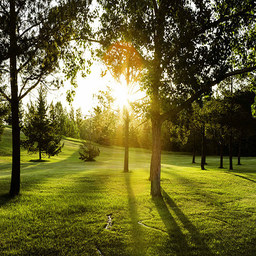
* 실험5로 생성된 유키요에
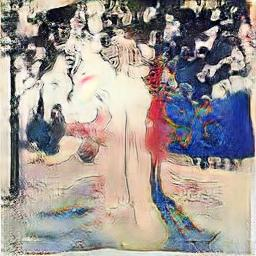
* 실험6로 생성된 유키요에
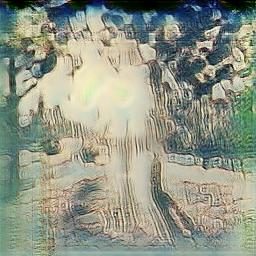




* 실험5
우키요에의 색감과 평면성을 잘 표현되었고 약간 과장되었지만 스타일이 명확함

* 실험6
더 자연스럽고 부드러운 변환 원본 사진의 정보를 더 많이 보존하였음 하지만 우키요에 특유의 강렬함 부족한 것 같다.

>> 논문은 "cycle consistency is sometimes too strong"이라며 pixel-level 제약이 realistic한 결과를 방해한다고 주장했다. Horse2zebra에서 얼룩말 무늬가 불완전하게 제거된 것을 cycle consistency가 과도하기 때문으로 분석했다. 하지만 photo2ukiyo에서는 정반대였다. 실험6에서 논문의 방법(feature-level cycle consistency, lambda decay)을 적용하자 변환이 부드러워졌지만 우키요에 특유의 강렬한 색감과 평면성이 약화되었다. Horse2zebra는 texture 제거가, photo2ukiyo는 강한 스타일 표현이 목표이므로 cycle consistency 완화가 오히려 역효과를 낸 것같다.




### 종합 분석
실험 구성실험 1: 데이터 전처리 방법 비교
실험 2: 학습률, 배치 크기, 손실 함수 등 하이퍼파라미터 최적화
실험 3: 업샘플링 방식, Patch 크기, Normalization 비교
실험 4: Generator와 Discriminator의 Normalization 조합 탐색
실험 5: 최적 구성에 데이터 전처리 미세 조정
실험 6: 논문 방법론(Better Cycles) 적용

* 최종결과

| 구성                  | FID        |
| ------------------- | ---------- |
| **A_light_jitter**  | **175.89** |

* 1. 데이터 전처리

> Minimal augmentation이 효과적: 과도한 변형(strong augmentation)은 오히려 성능 저하 (FID 230~232)
Light color jitter가 최적: 밝기·대비를 0.05 수준으로 아주 약하게 조정하는 것이 가장 좋았음 (FID 175.89)
데이터 본래의 특성을 유지하면서 최소한의 변형만 주는 것이 중요한 것 같다.

* 2. 하이퍼파라미터

> BCE Loss > MSE Loss: BCE가 MSE보다 확실히 우수 (200.11 vs 208 ~ 225) 학습률 0.0002가 최적이였다 , 학습률 0.0005는 학습이 불안정했다.
Lambda 값 1~10이 안정적: 너무 크거나 작으면 성능 저하
Adam optimizer 안정적: RMSprop은 성능이 나빴다.

* 3. 네트워크 구조

> Bilinear 업샘플링이 압도적: Nearest나 ConvTranspose2d보다 훨씬 우수 (FID 186.04)
Patch4가 최적: Patch3(208), Patch5(230)보다 좋았다.
InstanceNorm이 안정적: 작은 배치 환경에서 BatchNorm(229.50)보다 우수

* 4. Generator-Discriminator 조합

> G-InstanceNorm / D-BatchNorm이 최적 (FID 176.01)
Generator는 스타일 제어, Discriminator는 판별 안정성 확보
각 네트워크 역할에 맞는 normalization 선택이 중요

* 5. 논문 방법론의 한계

> 실험 6에서 오히려 성능 저하 (FID 213~245)
Horse2zebra에서 효과적이었던 방법이 photo2ukiyo에서는 맞지 않음
원인: Horse2zebra는 단순한 texture 변환이지만, photo2ukiyo는 복잡한 style 변환
우키요에는 구조 보존이 중요한데, cycle consistency를 너무 완화하면 구조가 무너짐

## 8. 결과 이미지
* 실험 1: ./cyclegan_results/
* 실험 2: ./cyclegan_experiments/
* 실험 3: ./cyclegan_advanced/ 
* 실험 4: ./cyclegan_gd_separate/
* 실험 5: ./cyclegan_albumentations_optimized/
* 실험 6: ./cyclegan_Better_Cycles_results/